**Visualise Preprocessing Steps**

In [1]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
import numpy as np
import ants
import antspynet
import torch
import torchio as tio
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
t1_mri = ants.image_read(os.path.join(os.getenv('PROJECT_ROOT'), 'data', 'raw_sample', 'IXI425-IOP-0988-T1.nii.gz'))
t2_mri = ants.image_read(os.path.join(os.getenv('PROJECT_ROOT'), 'data', 'raw_sample', 'IXI425-IOP-0988-T2.nii.gz'))

### 1. Reorientation

In [3]:
reoriented_t1_mri = ants.reorient_image2(t1_mri, orientation='RAS')
reoriented_t2_mri = ants.reorient_image2(t2_mri, orientation='RAS')

print('Orientation Before (T1):', t1_mri.orientation, '/ Orientation After (T1):', reoriented_t1_mri.orientation)
print('Orientation Before (T2):', t2_mri.orientation, '/ Orientation After (T2):', reoriented_t2_mri.orientation)

Orientation Before (T1): AIL / Orientation After (T1): RAS
Orientation Before (T2): RPI / Orientation After (T2): RAS


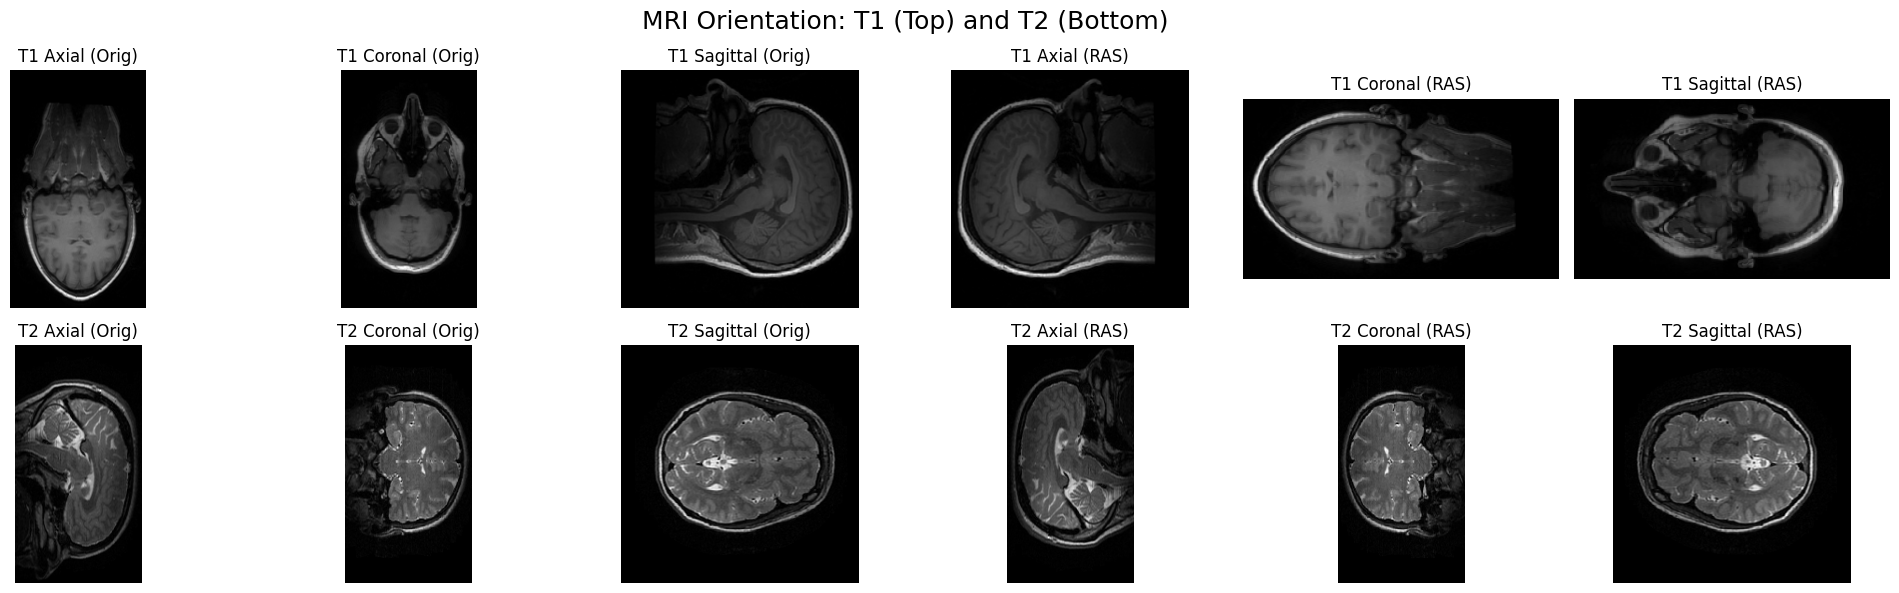

In [4]:
# Convert to numpy
t1_orig_np = t1_mri.numpy()
t1_ras_np = reoriented_t1_mri.numpy()
t2_orig_np = t2_mri.numpy()
t2_ras_np = reoriented_t2_mri.numpy()

# Get mid slices
z1, y1, x1 = t1_orig_np.shape
z1r, y1r, x1r = t1_ras_np.shape
z2, y2, x2 = t2_orig_np.shape
z2r, y2r, x2r = t2_ras_np.shape

# Create subplot: 2 rows (T1, T2), 6 columns (3 views before and after)
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
fig.suptitle('MRI Orientation: T1 (Top) and T2 (Bottom)', fontsize=18)

# T1 Original
axes[0, 0].imshow(t1_orig_np[z1 // 2, :, :], cmap='gray')
axes[0, 0].set_title('T1 Axial (Orig)')
axes[0, 1].imshow(t1_orig_np[:, y1 // 2, :], cmap='gray')
axes[0, 1].set_title('T1 Coronal (Orig)')
axes[0, 2].imshow(t1_orig_np[:, :, x1 // 2], cmap='gray')
axes[0, 2].set_title('T1 Sagittal (Orig)')

# T1 Reoriented
axes[0, 3].imshow(t1_ras_np[z1r // 2, :, :], cmap='gray')
axes[0, 3].set_title('T1 Axial (RAS)')
axes[0, 4].imshow(t1_ras_np[:, y1r // 2, :], cmap='gray')
axes[0, 4].set_title('T1 Coronal (RAS)')
axes[0, 5].imshow(t1_ras_np[:, :, x1r // 2], cmap='gray')
axes[0, 5].set_title('T1 Sagittal (RAS)')

# T2 Original
axes[1, 0].imshow(t2_orig_np[z2 // 2, :, :], cmap='gray')
axes[1, 0].set_title('T2 Axial (Orig)')
axes[1, 1].imshow(t2_orig_np[:, y2 // 2, :], cmap='gray')
axes[1, 1].set_title('T2 Coronal (Orig)')
axes[1, 2].imshow(t2_orig_np[:, :, x2 // 2], cmap='gray')
axes[1, 2].set_title('T2 Sagittal (Orig)')

# T2 Reoriented
axes[1, 3].imshow(t2_ras_np[z2r // 2, :, :], cmap='gray')
axes[1, 3].set_title('T2 Axial (RAS)')
axes[1, 4].imshow(t2_ras_np[:, y2r // 2, :], cmap='gray')
axes[1, 4].set_title('T2 Coronal (RAS)')
axes[1, 5].imshow(t2_ras_np[:, :, x2r // 2], cmap='gray')
axes[1, 5].set_title('T2 Sagittal (RAS)')

# Remove axis ticks
for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

### 2. Intensity Normalisation

In [5]:
t1_torchio_image = tio.ScalarImage(tensor=torch.from_numpy(reoriented_t1_mri.numpy()).unsqueeze(0))
t1_brain_mask = antspynet.brain_extraction(reoriented_t1_mri, modality="t1", verbose=False)
t1_torchio_mask = tio.ScalarImage(tensor=torch.from_numpy(t1_brain_mask.numpy()).unsqueeze(0))
t1_binary_mask = (t1_torchio_mask.data > 0.9).to(torch.uint8)
t1_extracted_image = t1_torchio_image.data * t1_binary_mask
t1_normalised_image = tio.RescaleIntensity(percentiles=(0, 99), masking_method=lambda x: x > 0)(t1_extracted_image)

t2_torchio_image = tio.ScalarImage(tensor=torch.from_numpy(reoriented_t2_mri.numpy()).unsqueeze(0))
t2_brain_mask = antspynet.brain_extraction(reoriented_t2_mri, modality="t2", verbose=False)
t2_torchio_mask = tio.ScalarImage(tensor=torch.from_numpy(t2_brain_mask.numpy()).unsqueeze(0))
t2_binary_mask = (t2_torchio_mask.data > 0.9).to(torch.uint8)
t2_extracted_image = t2_torchio_image.data * t2_binary_mask
t2_normalised_image = tio.RescaleIntensity(percentiles=(0, 99), masking_method=lambda x: x > 0)(t2_extracted_image)

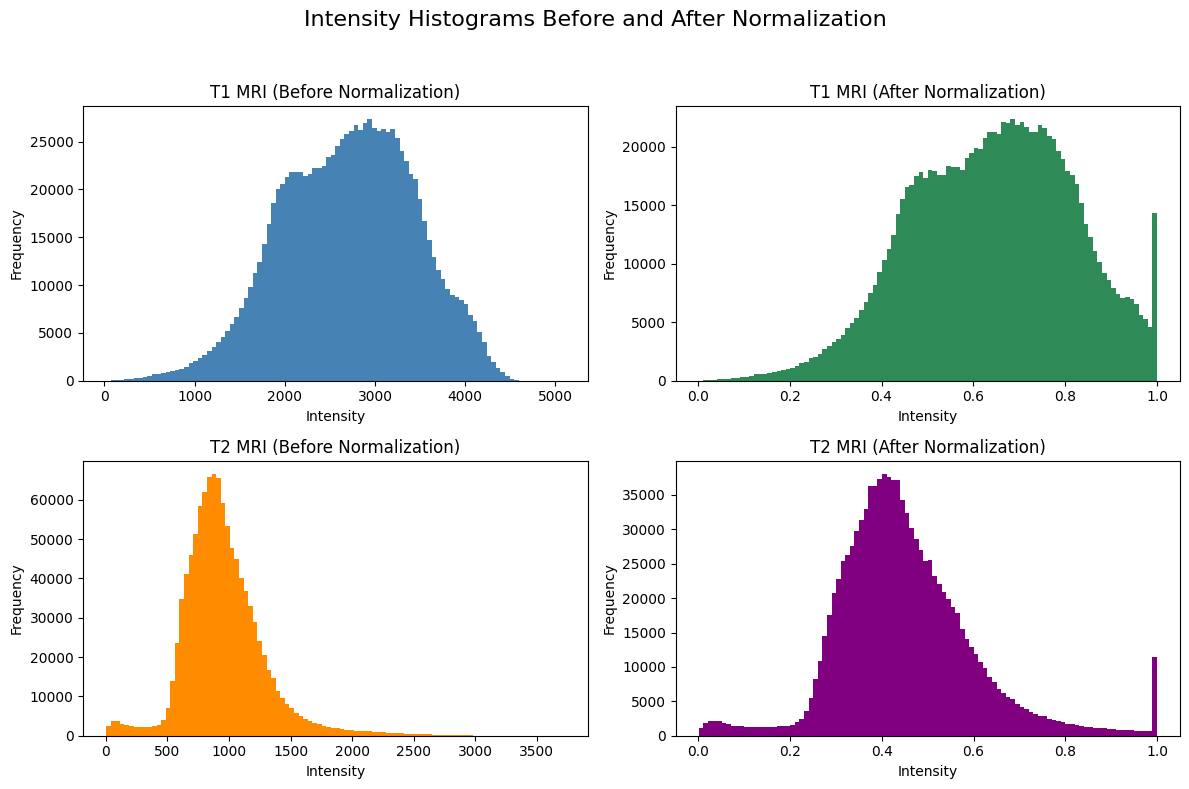

In [6]:
# Convert tensor to NumPy (remove batch and channel dims)
t1_before = t1_extracted_image.squeeze().numpy()
t1_after = t1_normalised_image.squeeze().numpy()
t2_before = t2_extracted_image.squeeze().numpy()
t2_after = t2_normalised_image.squeeze().numpy()

# Plot histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Intensity Histograms Before and After Normalization', fontsize=16)

# T1 before normalization
axes[0, 0].hist(t1_before[t1_before > 0].flatten(), bins=100, color='steelblue')
axes[0, 0].set_title('T1 MRI (Before Normalization)')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')

# T1 after normalization
axes[0, 1].hist(t1_after[t1_after > 0].flatten(), bins=100, color='seagreen')
axes[0, 1].set_title('T1 MRI (After Normalization)')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')

# T2 before normalization
axes[1, 0].hist(t2_before[t2_before > 0].flatten(), bins=100, color='darkorange')
axes[1, 0].set_title('T2 MRI (Before Normalization)')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Frequency')

# T2 after normalization
axes[1, 1].hist(t2_after[t2_after > 0].flatten(), bins=100, color='purple')
axes[1, 1].set_title('T2 MRI (After Normalization)')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 3. Resampling

In [7]:
t1_resampled = tio.Resample((1, 1, 1))(t1_normalised_image)
t2_resampled = tio.Resample((1, 1, 1))(t2_normalised_image)

### 4. Resizing

In [8]:
t1_resized = tio.Resize(target_shape=128, image_interpolation='linear')(t1_resampled)
t2_resized = tio.Resize(target_shape=128, image_interpolation='linear')(t2_resampled)

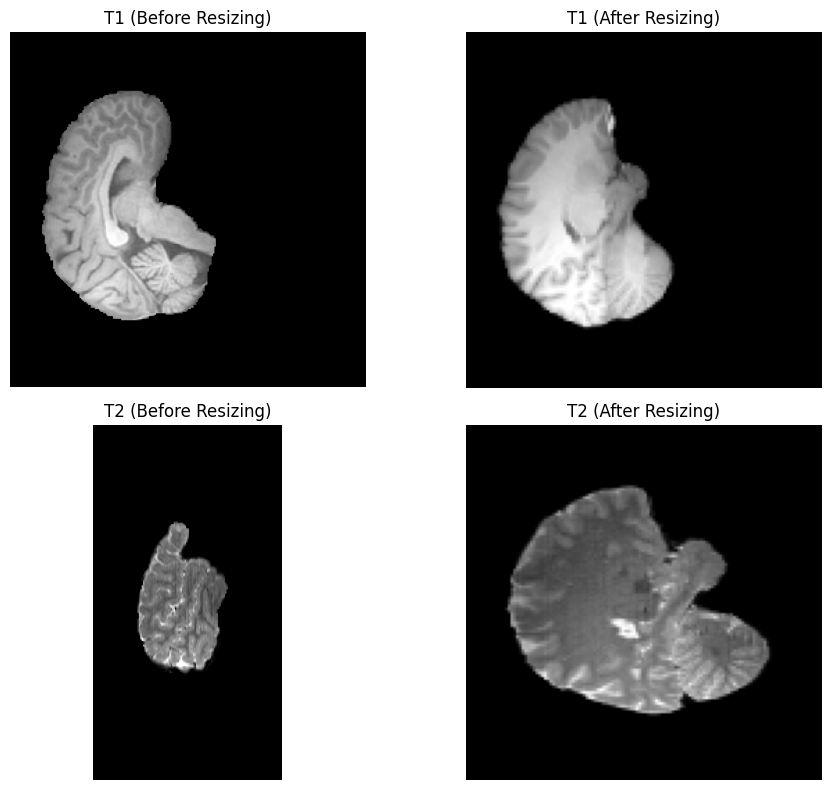

In [9]:
# Convert the resampled and resized tensors back to numpy arrays for visualization
t1_resampled_np = t1_resampled.data.squeeze().numpy() 
t2_resampled_np = t2_resampled.data.squeeze().numpy()  

t1_resized_np = t1_resized.data.squeeze().numpy()  
t2_resized_np = t2_resized.data.squeeze().numpy()  

# Select a slice from the middle of the image along the axial plane
middle_slice = t1_resampled_np.shape[0] // 2  

# Plot the images: before and after resizing for both T1 and T2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot T1 Resampled (Before Resizing)
axes[0, 0].imshow(t1_resampled_np[middle_slice, :, :], cmap='gray')
axes[0, 0].set_title('T1 (Before Resizing)')
axes[0, 0].axis('off')

# Plot T1 Resized (After Resizing)
axes[0, 1].imshow(t1_resized_np[middle_slice, :, :], cmap='gray')
axes[0, 1].set_title('T1 (After Resizing)')
axes[0, 1].axis('off')

# Plot T2 Resampled (Before Resizing)
axes[1, 0].imshow(t2_resampled_np[middle_slice, :, :], cmap='gray')
axes[1, 0].set_title('T2 (Before Resizing)')
axes[1, 0].axis('off')

# Plot T2 Resized (After Resizing)
axes[1, 1].imshow(t2_resized_np[middle_slice, :, :], cmap='gray')
axes[1, 1].set_title('T2 (After Resizing)')
axes[1, 1].axis('off')

# Show the plot
plt.tight_layout()
plt.show()

In [10]:
print('Before Resizing Shape (T1):', t1_resampled_np.shape)
print('After Resizing Shape (T1):', t1_resized_np.shape)
print('Before Resizing Shape (T2):', t2_resampled_np.shape)
print('After Resizing Shape (T2):', t2_resized_np.shape)

Before Resizing Shape (T1): (146, 256, 256)
After Resizing Shape (T1): (128, 128, 128)
Before Resizing Shape (T2): (256, 256, 136)
After Resizing Shape (T2): (128, 128, 128)


### 5. Add Noise (Optional)

In [11]:
shape = (1, 1, 16, 16, 16)
gaussian_noise = torch.rand(shape) * 0.2
high_resolution_noise = F.interpolate(gaussian_noise, size=128, mode='trilinear')
t1_augmented_noise = tio.transforms.RandomAffine(scales=0, degrees=0, translation=5)(high_resolution_noise.squeeze(0))
t2_augmented_noise = tio.transforms.RandomAffine(scales=0, degrees=0, translation=5)(high_resolution_noise.squeeze(0))

In [12]:
t1_resampled_mask = tio.Resample((1, 1, 1))(t1_binary_mask)
t1_resized_mask = tio.Resize(target_shape=128, image_interpolation='linear')(t1_resampled_mask)

t1_noisy_image = t1_resized.clone()
t1_noisy_image += t1_augmented_noise
t1_noisy_image *= t1_resized_mask

t2_resampled_mask = tio.Resample((1, 1, 1))(t2_binary_mask)
t2_resized_mask = tio.Resize(target_shape=128, image_interpolation='linear')(t2_resampled_mask)

t2_noisy_image = t2_resized.clone()
t2_noisy_image += t2_augmented_noise
t2_noisy_image *= t2_resized_mask

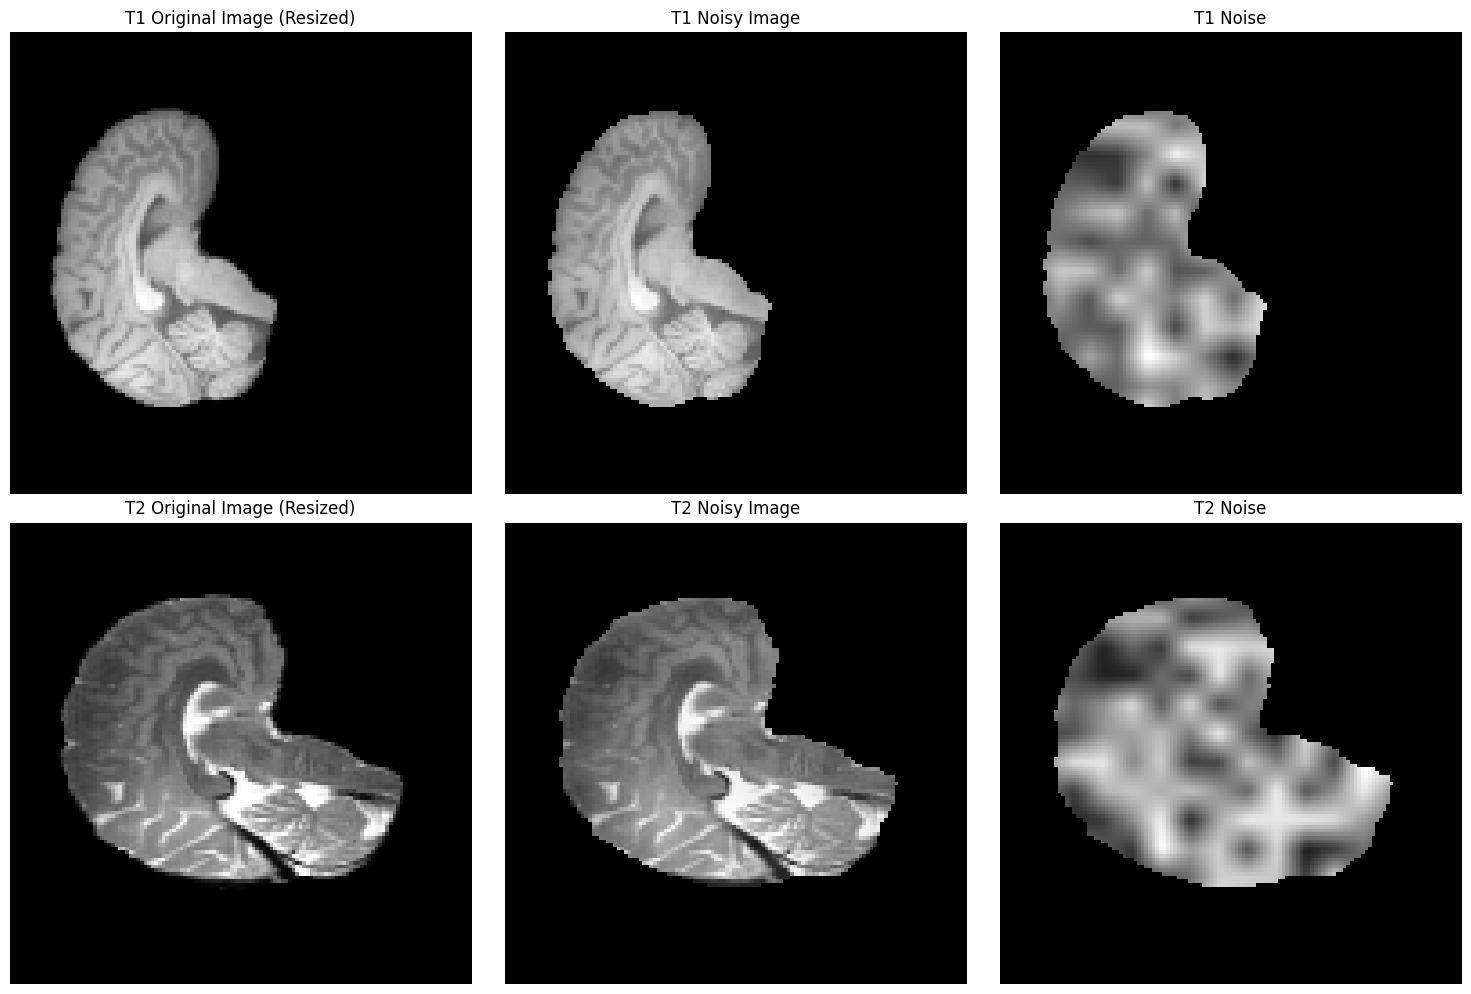

In [13]:
# Convert the noisy image tensor back to numpy for visualization
t1_noisy_image_np = t1_noisy_image.data.squeeze().numpy() 
t1_augmented_noise_np = t1_augmented_noise.squeeze().numpy() 
t1_augmented_noise_np *= t1_resized_mask.data.squeeze().numpy()  

t2_noisy_image_np = t2_noisy_image.data.squeeze().numpy()  
t2_augmented_noise_np = t2_augmented_noise.squeeze().numpy()  
t2_augmented_noise_np *= t2_resized_mask.data.squeeze().numpy()  

# Select a slice from the middle of the image along the axial plane
middle_slice = t1_resized_np.shape[0] // 2  # Middle slice for axial view

# Create a 2x3 subplot for displaying images side by side (T1 and T2 modalities)
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

# Plot the T1 images
ax[0, 0].imshow(t1_resized_np[middle_slice, :, :], cmap='gray')
ax[0, 0].set_title('T1 Original Image (Resized)')
ax[0, 0].axis('off')

ax[0, 1].imshow(t1_noisy_image_np[middle_slice, :, :], cmap='gray')
ax[0, 1].set_title('T1 Noisy Image')
ax[0, 1].axis('off')

ax[0, 2].imshow(t1_augmented_noise_np[middle_slice, :, :], cmap='gray')
ax[0, 2].set_title('T1 Noise')
ax[0, 2].axis('off')

# Plot the T2 images
ax[1, 0].imshow(t2_resized_np[middle_slice, :, :], cmap='gray')
ax[1, 0].set_title('T2 Original Image (Resized)')
ax[1, 0].axis('off')

ax[1, 1].imshow(t2_noisy_image_np[middle_slice, :, :], cmap='gray')
ax[1, 1].set_title('T2 Noisy Image')
ax[1, 1].axis('off')

ax[1, 2].imshow(t2_augmented_noise_np[middle_slice, :, :], cmap='gray')
ax[1, 2].set_title('T2 Noise')
ax[1, 2].axis('off')

# Show the plot
plt.tight_layout()
plt.show()